# C25067512 - CMT316 Coursework 1 - Part 2 - BBC News Text Classification

### In this notebook, a text classification model is developed which can classify text into five categories
- Tech
- Business
- Sport
- Politics
- Entertainment

### The provided BBC News dataset is split into those 5 categories and contains article text in each file.

### The implementation follows a Machine Learning Pipeline (NLP Pipeline). The table of contents is listed below
0. Data Collection (Dataset is provided)
1. [Data Preparation](#1-data-preparation) (data cleaning, preprocessing, feature engineering and feature selection)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis) (statistics, research questions)
3. [Feature Engineering and Feature Selection](#3-feature-engineering-and-feature-selection)
4. [Machine Learning](#4-machine-learning) (model training, model selection, evaluation strategy)
5. [Evaluation and Visualisation](#5-evaluation-and-visualisation)

**All references used to implement the code are formally cited in the report bibliography.**

Install the spacy model:

In [19]:
# python3 -m spacy download en_core_web_sm

All libraries required to run this notebook are imported below.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
nlp = spacy.load('en_core_web_sm')

from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, learning_curve
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
import scipy.sparse as sp

# 1. Data Preparation
This step involves performing data cleaning (preprocessing) on the dataset, feature engineering and feature selection.

## 1.1 Loading the Dataset

Loading the dataset

In [21]:
# --- Configuration ---
BBC_DATA_PATH = 'datasets_coursework1/bbc/'

In [22]:
# load dataset
CATEGORIES = ['business', 'entertainment', 'politics', 'sport', 'tech']

#dataset is split into bbc/category/file.txt, containing the text of the article

#load the data into a pandas dataframe, with columns 'text' and 'category' (label)
data = []

for category in CATEGORIES:
    category_path = BBC_DATA_PATH + category + '/'
    for filename in os.listdir(category_path):
        file_path = os.path.join(category_path, filename)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read()
        except UnicodeDecodeError: #some files may not be utf-8 encoded, try latin-1 encoding
            with open(file_path, 'r', encoding='latin-1') as f:
                text = f.read()
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
            continue
        data.append({'text': text, 'category': category})

df = pd.DataFrame(data)

#verify length of dataset with paper
print(f"Number of articles: {len(df)}")
print(f"Number of articles per category:\n{df['category'].value_counts()}")
#take full width
pd.set_option('display.max_colwidth', None)
df.head()

Number of articles: 2225
Number of articles per category:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


,text,category
0,"UK economy facing 'major risks'\n\nThe UK manufacturing sector will continue to face ""serious challenges"" over the next two years, the British Chamber of Commerce (BCC) has said.\n\nThe group's quarterly survey of companies found exports had picked up in the last three months of 2004 to their best levels in eight years. The rise came despite exchange rates being cited as a major concern. However, the BCC found the whole UK economy still faced ""major risks"" and warned that growth is set to slow. It recently forecast economic growth will slow from more than 3% in 2004 to a little below 2.5% in both 2005 and 2006.\n\nManufacturers' domestic sales growth fell back slightly in the quarter, the survey of 5,196 firms found. Employment in manufacturing also fell and job expectations were at their lowest level for a year.\n\n""Despite some positive news for the export sector, there are worrying signs for manufacturing,"" the BCC said. ""These results reinforce our concern over the sector's persistent inability to sustain recovery."" The outlook for the service sector was ""uncertain"" despite an increase in exports and orders over the quarter, the BCC noted.\n\nThe BCC found confidence increased in the quarter across both the manufacturing and service sectors although overall it failed to reach the levels at the start of 2004. The reduced threat of interest rate increases had contributed to improved confidence, it said. The Bank of England raised interest rates five times between November 2003 and August last year. But rates have been kept on hold since then amid signs of falling consumer confidence and a slowdown in output. ""The pressure on costs and margins, the relentless increase in regulations, and the threat of higher taxes remain serious problems,"" BCC director general David Frost said. ""While consumer spending is set to decelerate significantly over the next 12-18 months, it is unlikely that investment and exports will rise sufficiently strongly to pick up the slack.""\n",business
1,"Aids and climate top Davos agenda\n\nClimate change and the fight against Aids are leading the list of concerns for the first day of the World Economic Forum in the Swiss resort of Davos.\n\nSome 2,000 business and political leaders from around the globe will listen to UK Prime Minister Tony Blair's opening speech on Wednesday. Mr Blair will focus on Africa's development plans and global warming. Earlier in the day came an update on efforts to have 3 million people on anti-Aids drugs by the end of 2005. The World Health Organisation (WHO) said 700,000 people in poor countries were on life-extending drugs - up from 440,000 six months earlier but amounting to only 12% of the 5.8 million who needed them. A $2bn ""funding gap"" still stood in the way of hitting the 2005 target, the WHO said.\n\nThe themes to be stressed by Mr Blair - whose attendance was announced at the last minute - are those he wants to dominate the UK's chairmanship of the G8 group of industrialised states. Other issues to be discussed at the five-day conference range from China's\n\neconomic power to Iraq's future after this Sunday's elections. Aside from Mr Blair, more than 20 other world leaders are expected to attend including French President Jacques Chirac - due to speak by video link after bad weather delayed his helicopter - and South African President Thabo Mbeki, whose arrival has been delayed by Ivory Coast peace talks. The Ukraine's new president, Viktor Yushchenko, will also be there - as will newly elected Palestinian leader Mahmoud Abbas. Showbiz figures will also put in an appearance, from U2 frontman Bono - a well-known campaigner on trade and development issues - to Angelina Jolie, a goodwill campaigner for the UN on refugees.\n\nUnlike previous years, protests against the WEF are expected to be muted. Anti-globalisation campaigners have called off a demonstration planned for the weekend. At the same time, about 100,000 people are expected

### 1.2 Text Cleaning (entire dataset)

Although this part is performed before splitting the dataset, it does not lead to data leakage since only basic cleaning is performed such as newline character removal.

In [23]:
# clean the text by:
#remove \n characters and replace \n\n with a dot (headline)
# this allows us to treat headline as the first sentence of the article, which may be useful for classification

df['text'] = df['text'].str.replace('\n\n', '. ', n=1) #treat first headline as first sentence only (n=1 replaces only the first occurrence).
df['text'] = df['text'].str.replace('\n', ' ')


print(df.isnull().sum())#check for missing values
df = df.dropna()#remove any rows with missing values
df = df.drop_duplicates()#remove any duplicate rows
df['text'] = df['text'].str.strip()#remove any leading or trailing whitespace from the text

df.head()

text        0
category    0
dtype: int64


,text,category
0,"UK economy facing 'major risks'. The UK manufacturing sector will continue to face ""serious challenges"" over the next two years, the British Chamber of Commerce (BCC) has said. The group's quarterly survey of companies found exports had picked up in the last three months of 2004 to their best levels in eight years. The rise came despite exchange rates being cited as a major concern. However, the BCC found the whole UK economy still faced ""major risks"" and warned that growth is set to slow. It recently forecast economic growth will slow from more than 3% in 2004 to a little below 2.5% in both 2005 and 2006. Manufacturers' domestic sales growth fell back slightly in the quarter, the survey of 5,196 firms found. Employment in manufacturing also fell and job expectations were at their lowest level for a year. ""Despite some positive news for the export sector, there are worrying signs for manufacturing,"" the BCC said. ""These results reinforce our concern over the sector's persistent inability to sustain recovery."" The outlook for the service sector was ""uncertain"" despite an increase in exports and orders over the quarter, the BCC noted. The BCC found confidence increased in the quarter across both the manufacturing and service sectors although overall it failed to reach the levels at the start of 2004. The reduced threat of interest rate increases had contributed to improved confidence, it said. The Bank of England raised interest rates five times between November 2003 and August last year. But rates have been kept on hold since then amid signs of falling consumer confidence and a slowdown in output. ""The pressure on costs and margins, the relentless increase in regulations, and the threat of higher taxes remain serious problems,"" BCC director general David Frost said. ""While consumer spending is set to decelerate significantly over the next 12-18 months, it is unlikely that investment and exports will rise sufficiently strongly to pick up the slack.""",business
1,"Aids and climate top Davos agenda. Climate change and the fight against Aids are leading the list of concerns for the first day of the World Economic Forum in the Swiss resort of Davos. Some 2,000 business and political leaders from around the globe will listen to UK Prime Minister Tony Blair's opening speech on Wednesday. Mr Blair will focus on Africa's development plans and global warming. Earlier in the day came an update on efforts to have 3 million people on anti-Aids drugs by the end of 2005. The World Health Organisation (WHO) said 700,000 people in poor countries were on life-extending drugs - up from 440,000 six months earlier but amounting to only 12% of the 5.8 million who needed them. A $2bn ""funding gap"" still stood in the way of hitting the 2005 target, the WHO said. The themes to be stressed by Mr Blair - whose attendance was announced at the last minute - are those he wants to dominate the UK's chairmanship of the G8 group of industrialised states. Other issues to be discussed at the five-day conference range from China's economic power to Iraq's future after this Sunday's elections. Aside from Mr Blair, more than 20 other world leaders are expected to attend including French President Jacques Chirac - due to speak by video link after bad weather delayed his helicopter - and South African President Thabo Mbeki, whose arrival has been delayed by Ivory Coast peace talks. The Ukraine's new president, Viktor Yushchenko, will also be there - as will newly elected Palestinian leader Mahmoud Abbas. Showbiz figures will also put in an appearance, from U2 frontman Bono - a well-known campaigner on trade and development issues - to Angelina Jolie, a goodwill campaigner for the UN on refugees. Unlike previous years, protests against the WEF are expected to be muted. Anti-globalisation campaigners have called off a demonstration planned for the weekend. At the same time, about 100,000 people are expected to converge on the Brazilian 

### 1.3 Text Preprocessing using Spacy

A TextPreprocessor sklearn transformer is defined here (lemmatization, stopword and punctuation removal). Instead of applying preprocessing to the entire dataset before splitting, TextPreprocessor is embedded inside each pipeline branch (TF-IDF and Lexical) so that it is fitted on the Train split only and then applied to Dev/Test, preventing data leakage.

POS and NER pipelines receive raw cleaned text directly for accurate spaCy tagging (lemmatized text degrades entity and POS quality).

A preprocessed copy of the full dataset is created here for EDA visualisation only and plays no role in model training. df['text'] remains raw cleaned text.

In [24]:
df_before_preprocessing = df.copy()  #raw cleaned text (headline merged, whitespace cleaned) — for EDA

_preprocess_cache = {} #to avoid processing same text multiple times

def preprocess_text(text):
    """Lemmatize, lowercase, and remove stop words and punctuation using spaCy.
    Results are cached at module level to avoid reprocessing identical text."""
    if text in _preprocess_cache:
        return _preprocess_cache[text]
    doc = nlp(text)
    tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct: #remove stop words and punctuation
            tokens.append(token.lemma_.lower()) #lemmatize and lowercase
            # not removing numbers, they might be useful
    result = ' '.join(tokens) #join tokens back into a single string for vectorization
    _preprocess_cache[text] = result #cache result for reuse
    return result

class TextPreprocessor(BaseEstimator, TransformerMixin):
    """Sklearn-compatible transformer that applies spaCy text preprocessing"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [preprocess_text(text) for text in X]

#build df_after_preprocessing for EDA
df_after_preprocessing = df[['text', 'category']].copy()
df_after_preprocessing['text'] = df_after_preprocessing['text'].apply(preprocess_text)

print(f"Preprocessing cache populated: {len(_preprocess_cache)} entries (EDA-only; pipelines will reuse cache after split)")

Preprocessing cache populated: 2127 entries (EDA-only; pipelines will reuse cache after split)


### 1.4 Dataset Splits — Evaluation Strategy

The dataset is split into 70% Train, 15% Dev, and 15% Test:
- Train: used for fitting feature pipelines and hyperparameter tuning via 5-fold cross-validation.
- Dev: used in Phase 1 (feature pipeline comparison) and Phase 2.5
- Test: held out and evaluated once at the end.

Splits are stratified to maintain class balance across sets.

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(df['text'], df['category'], test_size=0.3, random_state=42, stratify=df['category'])  # 70% train, 30% temp (dev + test)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)  # 15% dev, 15% test
# overall 70% training, 15% dev, 15% test

#encode string labels to integers
le = LabelEncoder()
le.fit(CATEGORIES)  # fit on all categories to ensure consistent encoding
y_train = le.transform(y_train)
y_dev = le.transform(y_dev)
y_test = le.transform(y_test)

print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}") 
print(f"Number of training samples: {len(X_train)}")
print(f"Number of dev samples: {len(X_dev)}")
print(f"Number of test samples: {len(X_test)}")
print(f"Train: {len(X_train)}  Dev: {len(X_dev)}  Test: {len(X_test)}")

Label mapping: {np.str_('business'): np.int64(0), np.str_('entertainment'): np.int64(1), np.str_('politics'): np.int64(2), np.str_('sport'): np.int64(3), np.str_('tech'): np.int64(4)}
Number of training samples: 1488
Number of dev samples: 319
Number of test samples: 320
Train: 1488  Dev: 319  Test: 320


# 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the dataset's structure, class distribution, vocabulary characteristics, and common n-gram patterns.

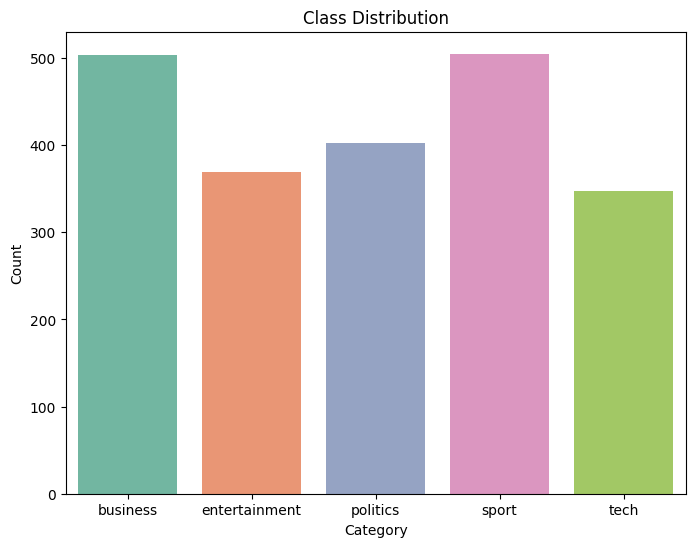

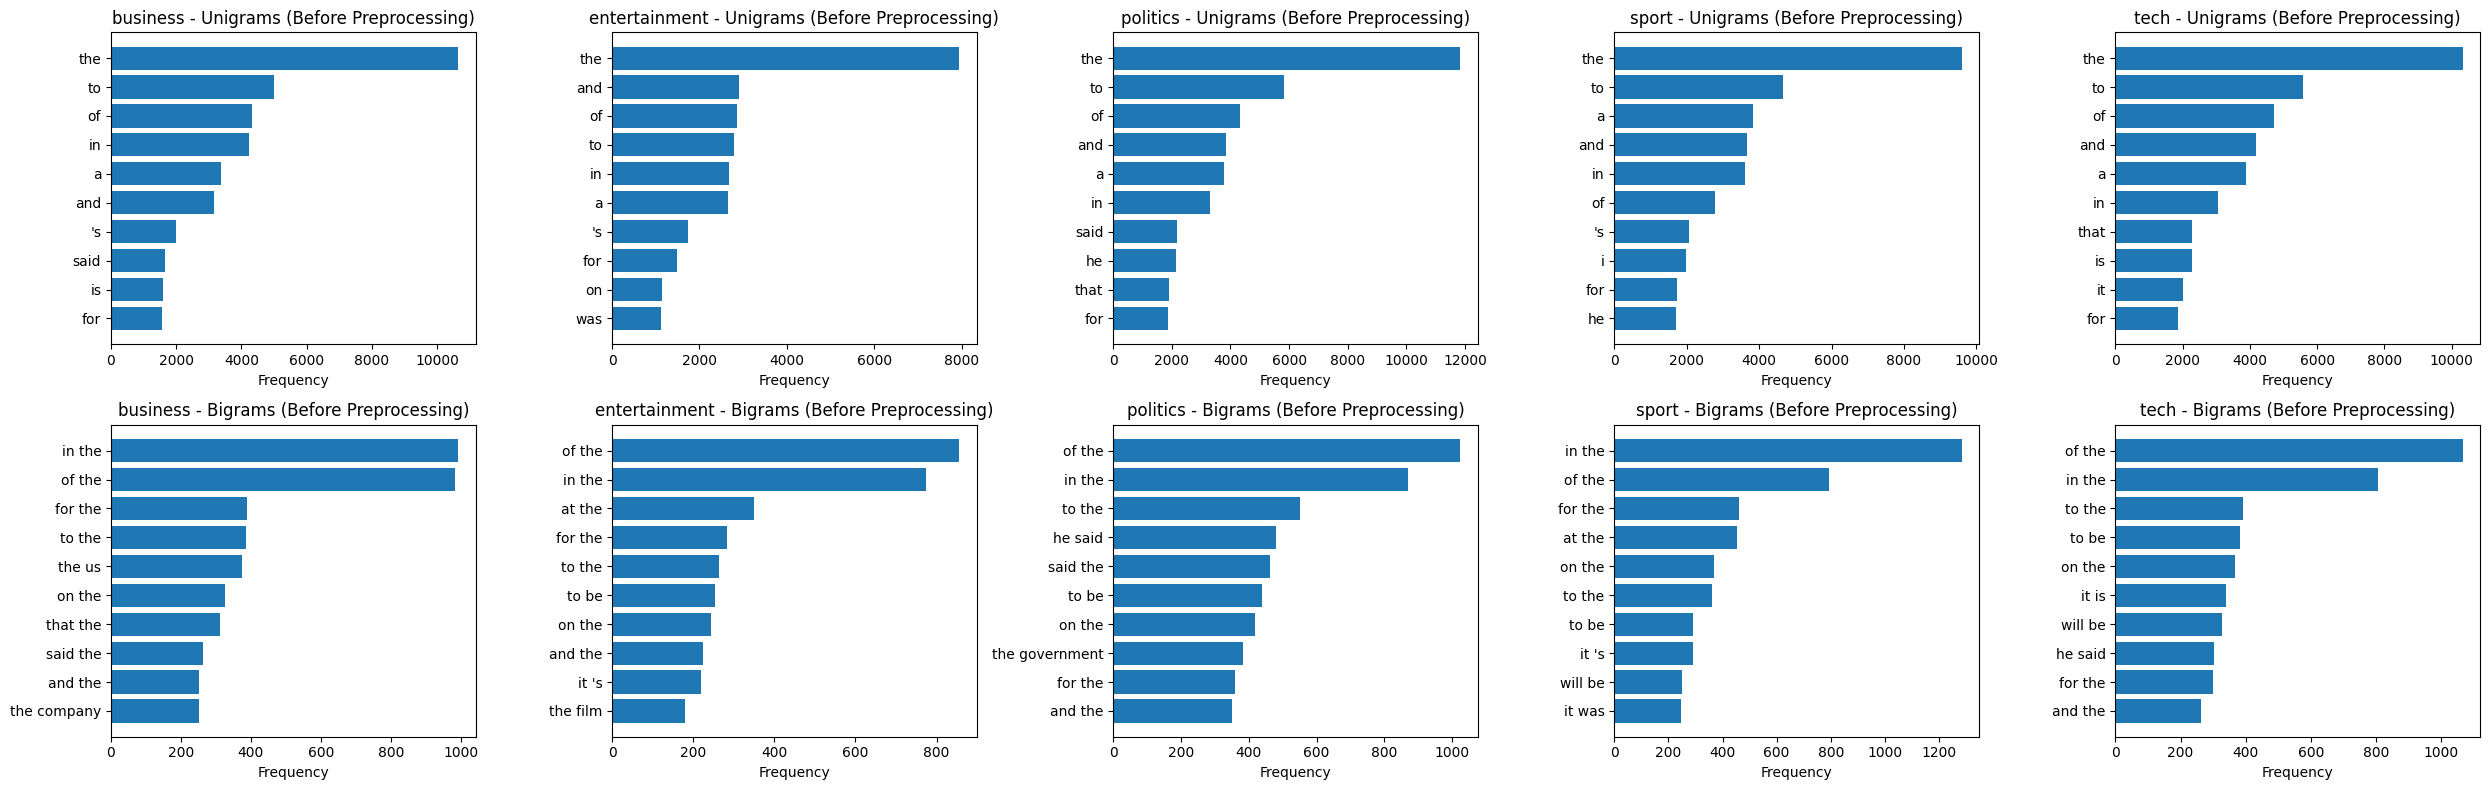

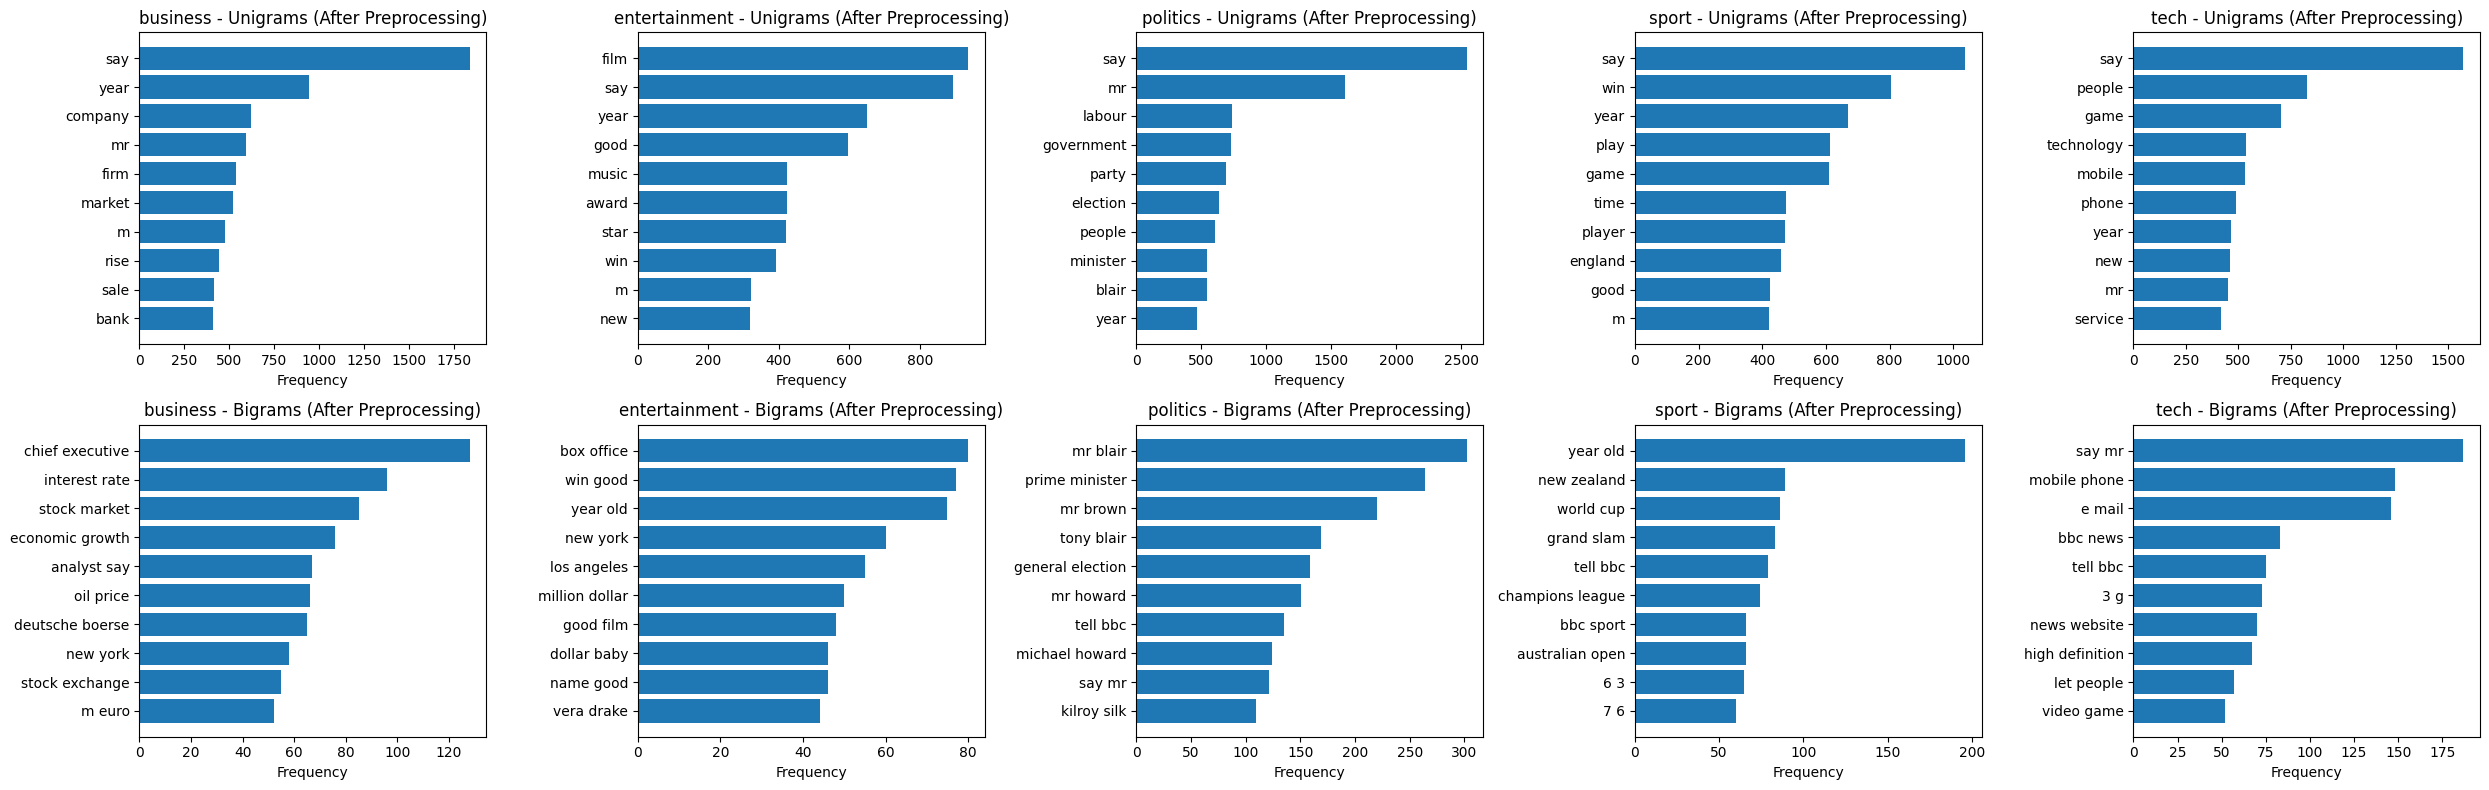

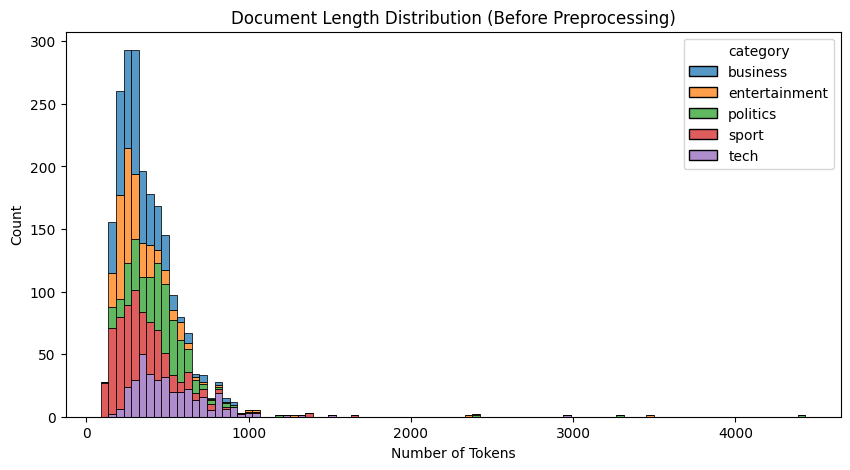

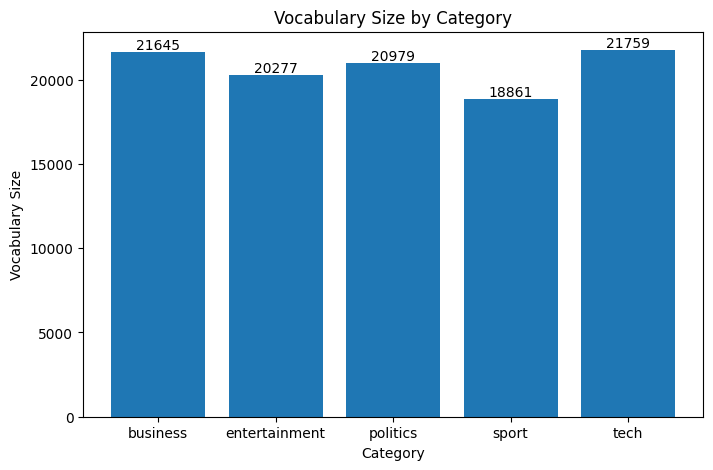

In [26]:
# class distribution plot
plt.figure(figsize=(8,6))
sns.countplot(x='category', data=df_before_preprocessing, hue='category', palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

# word tokenise
def tokenize_for_ngrams(text):
    tokens = word_tokenize(str(text))
    return [token.lower() for token in tokens if any(ch.isalnum() for ch in token)]

# get top n-grams for a given category
def get_top_ngrams(df, category, n=1, top_k=10):
    ngram_list = []
    for text in df[df['category'] == category]['text']: # iterate over all text in the category
        tokens = tokenize_for_ngrams(text)
        if len(tokens) >= n:
            ngram_list.extend([' '.join(g) for g in ngrams(tokens, n)])
    return Counter(ngram_list).most_common(top_k) #returns list of (ngram, count) tuples

def plot_top_ngrams(df, stage_label):
    fig, axes = plt.subplots(2, len(CATEGORIES), figsize=(5 * len(CATEGORIES), 8), squeeze=False) # 2 rows, 5 cols
    for col, category in enumerate(CATEGORIES):
        for row, n in enumerate([1, 2]):
            top_ngrams = get_top_ngrams(df, category, n=n, top_k=10) #top for category
            labels = [g for g, _ in top_ngrams][::-1] #reverse to have most frequent at the top of the barh plot
            counts = [c for _, c in top_ngrams][::-1]
            ax = axes[row, col] #row 0 for unigrams, row 1 for bigrams, col for category
            ax.barh(labels, counts)
            ngram_name = 'Unigrams' if n == 1 else 'Bigrams'
            ax.set_title(f'{category} - {ngram_name} ({stage_label})')
            ax.set_xlabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_top_ngrams(df_before_preprocessing, 'Before Preprocessing')
plot_top_ngrams(df_after_preprocessing, 'After Preprocessing')

#document length distribution (number of tokens) (plot)
df_before_preprocessing['token_count'] = df_before_preprocessing['text'].apply(lambda x: len(x.split()))
df_after_preprocessing['token_count'] = df_after_preprocessing['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(data=df_before_preprocessing, x='token_count', hue='category', multiple='stack')
plt.title('Document Length Distribution (Before Preprocessing)')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.show()

#vocabulary size between categories (plot)
def get_vocabulary_size(df, category):
    words = set()
    for text in df[df['category'] == category]['text']:
        words.update(text.split())
    return len(words)

vocabulary_sizes = []
for category in CATEGORIES:
    vocabulary_sizes.append(get_vocabulary_size(df_before_preprocessing, category))

plt.figure(figsize=(8,5))
bars = plt.bar(CATEGORIES, vocabulary_sizes)
plt.title('Vocabulary Size by Category')
plt.xlabel('Category')
plt.ylabel('Vocabulary Size')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}',
             ha='center', va='bottom')
plt.show()

# 3. Feature Engineering and Feature Selection

Features are engineered but they are candidates under experimental design. Feature selection is performed within each pipeline.

## 3.1 Feature Engineering

### 3.1.1 Feature 1: Tf-idf

TF-IDF (Term Frequency–Inverse Document Frequency) is a numerical statistic that reflects how important a word is to a document in a corpus. Unigrams and bigrams are used to capture both individual words and common two-word phrases.

In [27]:
# Feature 1: TF-IDF with unigrams and bigrams
# This is the mandatory word-frequency feature.
# sublinear_tf applies log(1+tf) normalization, L2 norm normalises document vectors.
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),# unigrams and bigrams
    max_features=10000,       
    sublinear_tf=True,# apply log normalization to tf
    min_df=3,#ignore when appearing in less than 3 docs
    max_df=0.95,#ignore when in more than 95% of docs
    norm='l2'
)

### 3.1.2 Feature 2: Lexical Features

Lexical features capture the richness and diversity of vocabulary used in a document.

In [28]:
# Feature 2: Lexical richness features
class LexicalFeatures(BaseEstimator, TransformerMixin):
    """Sklearn transformer for extracting lexical features from preprocessed text."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for text in X:
            tokens = text.split()
            num_tokens = len(tokens) if len(tokens) > 0 else 1 #to avoid division by 0 in ratio
            num_types = len(set(tokens))
            avg_word_length = np.mean([len(t) for t in tokens]) if tokens else 0 #mean length of words in the document
            long_words = sum(1 for t in tokens if len(t) > 6) #if length > 6
            features.append([
                num_tokens,# document length (token count)
                num_types, # vocabulary size
                num_types / num_tokens, # type-token ratio (lexical diversity)
                avg_word_length, # average word length
                long_words / num_tokens,# proportion of long words (>6 chars)
                np.std([len(t) for t in tokens]) if tokens else 0,  # word length std dev
            ])
        return np.array(features)

### 3.1.3 Feature 3: Syntactic Features

POS (Part-of-Speech) tag distributions capture the grammatical structure of documents. For example, sports articles may have higher verb frequency than business articles, which may be more noun-heavy.

In [29]:
# Feature 3: Syntactic features POS tag distribution using spaCy
class SyntacticFeatures(BaseEstimator, TransformerMixin):
    """Sklearn transformer for extracting syntactic features from raw text using spaCy."""
    def __init__(self):
        self.pos_tags = [
            'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ',
            'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT',
            'SCONJ', 'SYM', 'VERB', 'X'
        ] #POS tags from spacy (https://spacy.io/usage/linguistic-features#pos-tagging)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for text in X:
            doc = nlp(text)
            total = len(doc) if len(doc) > 0 else 1
            pos_counts = {tag: 0 for tag in self.pos_tags} #initialise counts for each POS tag
            for token in doc:
                if token.pos_ in pos_counts:
                    pos_counts[token.pos_] += 1
            #normalize by document length -> relative distribution
            pos_dist = [pos_counts[tag] / total for tag in self.pos_tags]
            # additional ratio: noun-to-verb ratio
            noun_verb_ratio = (pos_counts['NOUN'] + pos_counts['PROPN']) / max(pos_counts['VERB'], 1)
            pos_dist.append(noun_verb_ratio)
            features.append(pos_dist)
        return np.array(features)

### 3.1.4 Feature 4: Named Entity Recognition Feature

Named Entity Recognition (NER) identifies and classifies named entities in text (people, organisations, locations, dates, monetary values, etc.).

In [30]:
# Feature 4: Named Entity Recognition counts using spaCy
# Counts of entity types (PERSON, ORG, GPE, etc.) may differ across categories.

class NERFeatures(BaseEstimator, TransformerMixin):
    """Extract Named Entity counts from raw text using spaCy."""

    def __init__(self):
        self.entity_labels = ['PERSON', 'ORG', 'GPE', 'DATE', 'MONEY', 'NORP', 'FAC', 'LOC']
        #these entities may be particularly relevant for news articles (people, organisations, locations, dates, money amounts, etc.)
        #https://spacy.io/usage/linguistic-features#named-entities

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for text in X:
            doc = nlp(text)
            entity_counts = {label: 0 for label in self.entity_labels} #initialise counts for each entity type
            for ent in doc.ents:
                if ent.label_ in entity_counts:
                    entity_counts[ent.label_] += 1
            features.append([entity_counts[label] for label in self.entity_labels])
        return np.array(features)

### 3.1.5 Feature Union Exploration

The FeatureUnion below combines all feature branches for EDA, fitted on X_train (raw cleaned text). TF-IDF and Lexical branches include TextPreprocessor internally so they receive preprocessed lemmatised text fitted on Train only. Syntactic (POS) and NER branches receive raw cleaned text directly for accurate spaCy tagging.

In [31]:
# Combine all features using FeatureUnion + Pipeline
# TF-IDF and Lexical branches preprocess text internally via TextPreprocessor
#(fit on X_train only = no leakage to dev/test).
# syntactic (POS) and NER branches receive raw cleaned text directly for more accurate tagging.
feature_pipeline = FeatureUnion([
    ('tfidf', Pipeline([
        ('preprocess', TextPreprocessor()),#lemmatise/stopword removal on train only
        ('tfidf', tfidf_vectorizer),
    ])),
    ('lexical', Pipeline([
        ('preprocess', TextPreprocessor()),#lemmatise/stopword removal on train only
        ('extract', LexicalFeatures()),
        ('scale', StandardScaler()),
    ])),
    ('syntactic', Pipeline([
        ('extract', SyntacticFeatures()),#raw text for POS
        ('scale', StandardScaler()),
    ])),
    ('ner', Pipeline([
        ('extract', NERFeatures()),#raw text for NER
        ('scale', StandardScaler()),
    ])),
])

#fit on training data only, then transform dev and test
# X_train contains raw cleaned text
# preprocessing is handled inside each branch
X_train_features = feature_pipeline.fit_transform(X_train, y_train) #fit and transform on training data
X_dev_features = feature_pipeline.transform(X_dev)
X_test_features = feature_pipeline.transform(X_test)

print(f"Training feature matrix shape: {X_train_features.shape}")
print(f"Dev feature matrix shape: {X_dev_features.shape}")
print(f"Test feature matrix shape: {X_test_features.shape}")

#inspect feature group sizes
tfidf_size = len(feature_pipeline.transformer_list[0][1].named_steps['tfidf'].vocabulary_) #size of TF-IDF feature space (number of unigrams + bigrams)
lexical_size = 6
syntactic_size = len(SyntacticFeatures().pos_tags) + 1  # 17 POS + noun/verb ratio
ner_size = len(NERFeatures().entity_labels)
print(f"TF-IDF features: {tfidf_size}")
print(f"Lexical features: {lexical_size}")
print(f"Syntactic features: {syntactic_size}")
print(f"NER features: {ner_size}")
print(f"Total features: {tfidf_size + lexical_size + syntactic_size + ner_size}")


Training feature matrix shape: (1488, 10032)
Dev feature matrix shape: (319, 10032)
Test feature matrix shape: (320, 10032)
TF-IDF features: 10000
Lexical features: 6
Syntactic features: 18
NER features: 8
Total features: 10032


## 3.2 Feature Selection - Dimensionality Reduction

SelectKBest with mutual information is used to select the most informative features and reduce the feature space before model training.


In [32]:
#Exploratory Feature Importance via Mutual Information
#actual feature selection (fit on train, transform dev/test) happens in Phase 2.
import scipy.sparse as sp

X_train_features_dense = X_train_features.toarray() if sp.issparse(X_train_features) else X_train_features
mi_scores_eda = mutual_info_classif(X_train_features_dense, y_train.astype(int), random_state=42)
print(f"MI scores computed on {X_train_features_dense.shape[1]} total features (EDA only).")

MI scores computed on 10032 total features (EDA only).


### 3.2.1 Choosing k for SelectKBest

To justify the number of features retained by SelectKBest, a LinearSVC baseline is trained and evaluated on the Dev set for a range of k values. The k that maximises Dev Macro-F1 is selected and used in Phase 2.

k=   500  Dev Macro-F1: 0.9655
k=  1000  Dev Macro-F1: 0.9668
k=  2000  Dev Macro-F1: 0.9673
k=  3000  Dev Macro-F1: 0.9772
k=  5000  Dev Macro-F1: 0.9769


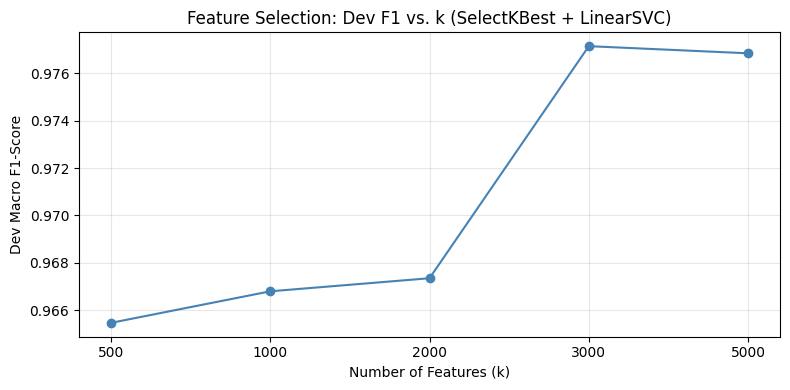


Selected k = 3000  (Dev F1 = 0.9772)


In [33]:
#k Selection via Dev F1

k_candidates = [500, 1000, 2000, 3000, 5000]
_X_train_feat_k = X_train_features.toarray() if sp.issparse(X_train_features) else X_train_features 
#convert to dense if sparse for SelectKBest, which doesn't support sparse input
_X_dev_feat_k   = X_dev_features.toarray()   if sp.issparse(X_dev_features)   else X_dev_features
total_features  = _X_train_feat_k.shape[1]

k_candidates_actual = [k for k in k_candidates if k < total_features]
k_labels = [str(k) for k in k_candidates if k < total_features] + ['all']

_baseline_k = LinearSVC(C=1, max_iter=50000, random_state=42) #SVC is a strong baseline
k_selection_results = []

for k_val, k_label in zip(k_candidates_actual, k_labels):
    _sel = SelectKBest(mutual_info_classif, k=k_val) #select top k features based on mutual information with the target
    _X_tr_k = _sel.fit_transform(_X_train_feat_k, y_train.astype(int)) #fit on train to select features
    _X_dv_k = _sel.transform(_X_dev_feat_k) #transform dev using the same feature selection (no refit to avoid leakage)
    _m = clone(_baseline_k) #clone to ensure a fresh model for each k
    _m.fit(_X_tr_k, y_train)
    _dev_f1 = f1_score(y_dev, _m.predict(_X_dv_k), average='macro')
    k_selection_results.append({'k': k_label, 'k_val': k_val, 'dev_f1': _dev_f1})
    print(f"k={k_label:>6}  Dev Macro-F1: {_dev_f1:.4f}")

_k_df = pd.DataFrame(k_selection_results)
#plot Dev F1 vs. k
plt.figure(figsize=(8, 4))
plt.plot(range(len(_k_df)), _k_df['dev_f1'], 'o-', color='steelblue')
plt.xticks(range(len(_k_df)), _k_df['k'])
plt.xlabel('Number of Features (k)')
plt.ylabel('Dev Macro F1-Score')
plt.title('Feature Selection: Dev F1 vs. k (SelectKBest + LinearSVC)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#select k with best Dev F1 and expose as k_features for Phase 2
_best_k_row = _k_df.loc[_k_df['dev_f1'].idxmax()]
k_features = _best_k_row['k_val']
print(f"\nSelected k = {k_features}  (Dev F1 = {_best_k_row['dev_f1']:.4f})")


### 3.3 Feature Importance

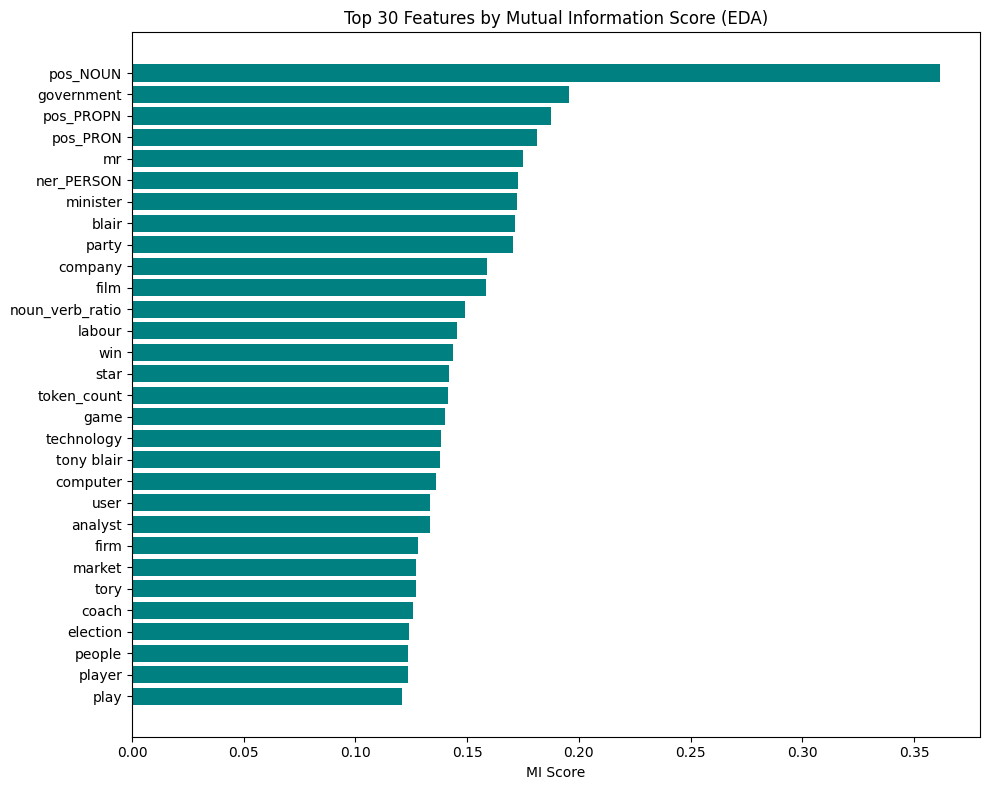

Non-TF-IDF features in top 3000 by MI: 31 / 32
  ['token_count', 'vocab_size', 'type_token_ratio', 'avg_word_len', 'long_word_prop', 'word_len_std', 'pos_ADJ', 'pos_ADP', 'pos_ADV', 'pos_AUX', 'pos_CCONJ', 'pos_DET', 'pos_NOUN', 'pos_NUM', 'pos_PART', 'pos_PRON', 'pos_PROPN', 'pos_PUNCT', 'pos_SCONJ', 'pos_SYM', 'pos_VERB', 'pos_X', 'noun_verb_ratio', 'ner_PERSON', 'ner_ORG', 'ner_GPE', 'ner_DATE', 'ner_MONEY', 'ner_NORP', 'ner_FAC', 'ner_LOC']


In [34]:
#top features by MI score for EDA
tfidf_names     = feature_pipeline.transformer_list[0][1].named_steps['tfidf'].get_feature_names_out().tolist()
lexical_names   = ['token_count', 'vocab_size', 'type_token_ratio', 'avg_word_len', 'long_word_prop', 'word_len_std']
syntactic_names = [f'pos_{tag}' for tag in SyntacticFeatures().pos_tags] + ['noun_verb_ratio']
ner_names       = [f'ner_{label}' for label in NERFeatures().entity_labels]
all_feature_names = tfidf_names + lexical_names + syntactic_names + ner_names

mi_df = pd.DataFrame({'feature': all_feature_names, 'mi_score': mi_scores_eda})
mi_df = mi_df.sort_values('mi_score', ascending=False)

top_n = 30
#plot top n features by MI score (descending order)
plt.figure(figsize=(10, 8))
top = mi_df.head(top_n)
plt.barh(top['feature'].values[::-1], top['mi_score'].values[::-1], color='teal')
plt.title(f'Top {top_n} Features by Mutual Information Score (EDA)')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

top_names = set(mi_df.head(3000)['feature'])
non_tfidf_in_top = [n for n in (lexical_names + syntactic_names + ner_names) if n in top_names]
print(f"Non-TF-IDF features in top 3000 by MI: {len(non_tfidf_in_top)} / {len(lexical_names + syntactic_names + ner_names)}")
# list the non-TF-IDF features that are in the top 3000 by MI score to see which specific ones are most informative
print(f"  {non_tfidf_in_top}")

# 4. Machine Learning

## 4.1 Phase 1: Feature Pipeline Comparison (Dev Set)
In this phase, different feature pipelines are compared using a fixed baseline model (LinearSVC with default hyperparameters). The Train set is used to fit the model, and the Dev set is used to evaluate the performance of each pipeline. The pipeline with the highest macro-F1 score on the Dev set is selected for the next phase.

In [35]:
#fit each feature combo on Train, evaluate on Dev with a fixed LinearSVC baseline.
# TF-IDF and Lexical branches include TextPreprocessor so lemmatisation is fitted
# on Train only (no leakage). POS/NER branches use raw cleaned text for accurate tagging.

feature_configs = {
    'tfidf_only': Pipeline([
        ('preprocess', TextPreprocessor()),
        ('tfidf', tfidf_vectorizer),
    ]),
    'tfidf+lexical': FeatureUnion([
        ('tfidf',    Pipeline([('preprocess', TextPreprocessor()), ('tfidf', tfidf_vectorizer)])),
        ('lexical',  Pipeline([('preprocess', TextPreprocessor()), ('extract', LexicalFeatures()), ('scale', StandardScaler())])),
    ]),
    'tfidf+lexical+syntactic': FeatureUnion([
        ('tfidf',     Pipeline([('preprocess', TextPreprocessor()), ('tfidf', tfidf_vectorizer)])),
        ('lexical',   Pipeline([('preprocess', TextPreprocessor()), ('extract', LexicalFeatures()), ('scale', StandardScaler())])),
        ('syntactic', Pipeline([('extract', SyntacticFeatures()), ('scale', StandardScaler())])),
    ]),
    'tfidf+lexical+syntactic+ner': FeatureUnion([
        ('tfidf',     Pipeline([('preprocess', TextPreprocessor()), ('tfidf', tfidf_vectorizer)])),
        ('lexical',   Pipeline([('preprocess', TextPreprocessor()), ('extract', LexicalFeatures()), ('scale', StandardScaler())])),
        ('syntactic', Pipeline([('extract', SyntacticFeatures()), ('scale', StandardScaler())])),
        ('ner',       Pipeline([('extract', NERFeatures()), ('scale', StandardScaler())])),
    ]),
}

baseline = LinearSVC(C=1, max_iter=50000, random_state=42)

phase1_results = []
for feat_name, feat_pipe in feature_configs.items():
    X_tr = feat_pipe.fit_transform(X_train) #fit and transform on train (preprocessing + feature extraction)
    X_dv = feat_pipe.transform(X_dev) #transform dev using the same pipeline (no refit to avoid leakage)

    model = clone(baseline) #clone to ensure a fresh model for each feature config
    model.fit(X_tr, y_train)
    dev_f1 = f1_score(y_dev, model.predict(X_dv), average='macro')

    phase1_results.append({'name': feat_name, 'dev_f1': dev_f1, 'pipeline': feat_pipe})
    print(f"{feat_name:40s}  Dev Macro-F1: {dev_f1:.4f}")

best_feat = max(phase1_results, key=lambda x: x['dev_f1']) #select the feature config with the highest Dev F1 score for Phase 2
best_feat_pipe = best_feat['pipeline'] 
print(f"\nBest features: {best_feat['name']} (Dev F1={best_feat['dev_f1']:.4f})")


tfidf_only                                Dev Macro-F1: 0.9838
tfidf+lexical                             Dev Macro-F1: 0.9834
tfidf+lexical+syntactic                   Dev Macro-F1: 0.9805
tfidf+lexical+syntactic+ner               Dev Macro-F1: 0.9863

Best features: tfidf+lexical+syntactic+ner (Dev F1=0.9863)


## 4.2 Phase 2: Model Selection and Hyperparameter Tuning (CV on Train)

Using the best feature pipeline from Phase 1:

1. Transform train features once with best_feat_pipe (fit on Train, transform Dev).
2. Select top k features with SelectKBest using the k from Section 3.2.1
3. Tune each candidate classifier's hyperparameters with GridSearchCV.

In [36]:

# 1: Transform features (fit on Train, apply to Dev)
X_train_feat = best_feat_pipe.fit_transform(X_train)
X_dev_feat   = best_feat_pipe.transform(X_dev)

# 2: Feature selection (fit on Train only) using k from previously
selector = SelectKBest(mutual_info_classif, k=k_features)

# convert to dense if sparse to avoid warnings from mutual_info_classif
X_train_feat_dense = X_train_feat.toarray() if sp.issparse(X_train_feat) else X_train_feat
X_dev_feat_dense   = X_dev_feat.toarray()   if sp.issparse(X_dev_feat)   else X_dev_feat

X_train_sel = selector.fit_transform(X_train_feat_dense, y_train.astype(int)) #fit selector on train to select top k features
X_dev_sel   = selector.transform(X_dev_feat_dense)
print(f"Feature selection: {X_train_feat_dense.shape[1]} -> {X_train_sel.shape[1]} features  (k={k_features})")

#3: hyperparameter tuning via GridSearchCV (5-fold CV on Train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidate_models = {
    'LinearSVC': (
        LinearSVC(random_state=42, max_iter=50000),
        {'C': [0.1, 1, 5, 10], 'class_weight': [None, 'balanced']},
    ),
    'LogisticRegression': (
        LogisticRegression(random_state=42, max_iter=5000, solver='saga'),
        {'C': [0.1, 1, 5, 10], 'class_weight': [None, 'balanced']},
    ),
    'SGDClassifier': (
        SGDClassifier(random_state=42, max_iter=5000),
        {'loss': ['hinge', 'modified_huber'], 'alpha': [1e-4, 1e-3, 1e-2], 'class_weight': [None, 'balanced']},
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_features': ['sqrt', 'log2'], 'class_weight': [None, 'balanced']},
    ),
}

phase2_results = []
for model_name, (clf, params) in candidate_models.items():
    grid = GridSearchCV(clf, params, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
    grid.fit(X_train_sel, y_train)

    cv_mean = grid.cv_results_['mean_test_score'][grid.best_index_] #best mean CV score for the model
    cv_std  = grid.cv_results_['std_test_score'][grid.best_index_] #std dev of CV scores for the best model

    phase2_results.append({
        'name':      model_name,
        'cv_f1':     cv_mean,
        'cv_std':    cv_std,
        'params':    grid.best_params_,
        'estimator': grid.best_estimator_,
    })
    print(f"{model_name:25s}  CV Macro-F1: {cv_mean:.4f} ± {cv_std:.4f}  Params: {grid.best_params_}")

best_result = max(phase2_results, key=lambda x: x['cv_f1']) #select the model with the highest mean CV F1 score
best_clf    = best_result['estimator'] 
print(f"\nBest model: {best_result['name']} (CV F1={best_result['cv_f1']:.4f} ± {best_result['cv_std']:.4f})")
print(f"  Params: {best_result['params']}")

# Summary table
phase2_df = pd.DataFrame([{
    'Model': r['name'],
    'CV Macro-F1': f"{r['cv_f1']:.4f}",
    'CV Std': f"± {r['cv_std']:.4f}",
    'Best Params': str(r['params']),
} for r in phase2_results])
print("\nModel Comparison Summary:")
print(phase2_df.to_string(index=False))


Feature selection: 10032 -> 3000 features  (k=3000)
LinearSVC                  CV Macro-F1: 0.9689 ± 0.0050  Params: {'C': 5, 'class_weight': 'balanced'}
LogisticRegression         CV Macro-F1: 0.9315 ± 0.0140  Params: {'C': 10, 'class_weight': 'balanced'}
SGDClassifier              CV Macro-F1: 0.9398 ± 0.0188  Params: {'alpha': 0.001, 'class_weight': None, 'loss': 'modified_huber'}
RandomForest               CV Macro-F1: 0.9583 ± 0.0070  Params: {'class_weight': 'balanced', 'max_features': 'log2', 'n_estimators': 200}

Best model: LinearSVC (CV F1=0.9689 ± 0.0050)
  Params: {'C': 5, 'class_weight': 'balanced'}

Model Comparison Summary:
             Model CV Macro-F1   CV Std                                                               Best Params
         LinearSVC      0.9689 ± 0.0050                                      {'C': 5, 'class_weight': 'balanced'}
LogisticRegression      0.9315 ± 0.0140                                     {'C': 10, 'class_weight': 'balanced'}
     SGDCla


## 4.3 Phase 2.5: Development Set Check

Verify that CV results generalise to unseen data.


In [37]:

# X_dev_sel already available from Phase 2 — just predict and score
y_dev_pred = best_clf.predict(X_dev_sel)
phase25_dev_f1 = f1_score(y_dev, y_dev_pred, average='macro')

print(f"Phase 2 CV Macro-F1:   {best_result['cv_f1']:.4f} ± {best_result['cv_std']:.4f}")
print(f"Phase 2.5 Dev Macro-F1: {phase25_dev_f1:.4f}")
print()
print(classification_report(y_dev, y_dev_pred, target_names=le.classes_, digits=4))


Phase 2 CV Macro-F1:   0.9689 ± 0.0050
Phase 2.5 Dev Macro-F1: 0.9771

               precision    recall  f1-score   support

     business     0.9733    0.9733    0.9733        75
entertainment     1.0000    0.9643    0.9818        56
     politics     0.9672    0.9833    0.9752        60
        sport     0.9870    1.0000    0.9935        76
         tech     0.9615    0.9615    0.9615        52

     accuracy                         0.9781       319
    macro avg     0.9778    0.9765    0.9771       319
 weighted avg     0.9782    0.9781    0.9780       319



## 4.4 Phase 3: Final Evaluation on Test

Once the best feature pipeline, model, and hyperparameters are selected, the final model is retrained on the combined Train and Dev sets. The Test set is used only once to evaluate the final model and report unbiased performance metrics.

In [38]:
#retrain everything (feature pipeline, selector, classifier) on Train+Dev, then evaluate on Test set.
X_train_dev   = pd.concat([X_train, X_dev]) #train+dev
y_train_dev   = np.concatenate([y_train, y_dev]) #train+dev labels

#1 Feature extraction, refit on Train+Dev
final_feat_pipe   = clone(best_feat_pipe)
X_train_dev_feat  = final_feat_pipe.fit_transform(X_train_dev)
X_test_feat       = final_feat_pipe.transform(X_test)

#2. Feature selection refit on Train+Dev
X_train_dev_feat_dense = X_train_dev_feat.toarray() if sp.issparse(X_train_dev_feat) else X_train_dev_feat
X_test_feat_dense      = X_test_feat.toarray() if sp.issparse(X_test_feat) else X_test_feat

final_selector    = SelectKBest(mutual_info_classif, k=k_features) #use the same k as determined before
X_train_dev_sel   = final_selector.fit_transform(X_train_dev_feat_dense, y_train_dev.astype(int))
X_test_sel        = final_selector.transform(X_test_feat_dense)

# 3. Classifier retrained on Train+Dev with best hyperparameters
final_clf = clone(best_clf)
final_clf.fit(X_train_dev_sel, y_train_dev)
y_pred = final_clf.predict(X_test_sel) #predict on test set

print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))


               precision    recall  f1-score   support

     business     0.9487    0.9737    0.9610        76
entertainment     0.9811    0.9455    0.9630        55
     politics     0.9831    0.9508    0.9667        61
        sport     0.9868    0.9868    0.9868        76
         tech     0.9259    0.9615    0.9434        52

     accuracy                         0.9656       320
    macro avg     0.9651    0.9637    0.9642       320
 weighted avg     0.9662    0.9656    0.9657       320



# 5. Evaluation and Visualisation

The final model is evaluated on the held-out Test set using accuracy, macro precision, macro recall, and macro F1-score. A confusion matrix (raw counts and normalised by true class) and a per-class F1 bar chart are produced.

FINAL TEST SET EVALUATION
Accuracy:        0.9656
Macro Precision: 0.9651
Macro Recall:    0.9637
Macro F1-Score:  0.9642

               precision    recall  f1-score   support

     business     0.9487    0.9737    0.9610        76
entertainment     0.9811    0.9455    0.9630        55
     politics     0.9831    0.9508    0.9667        61
        sport     0.9868    0.9868    0.9868        76
         tech     0.9259    0.9615    0.9434        52

     accuracy                         0.9656       320
    macro avg     0.9651    0.9637    0.9642       320
 weighted avg     0.9662    0.9656    0.9657       320



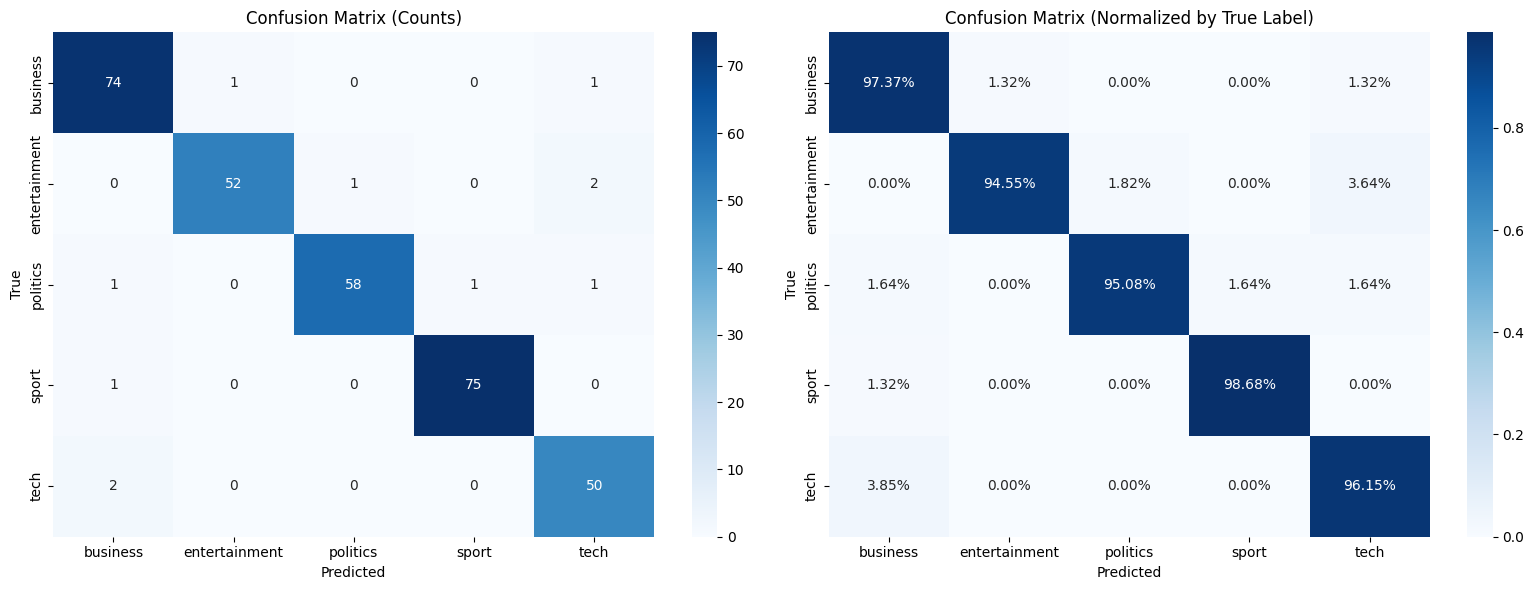

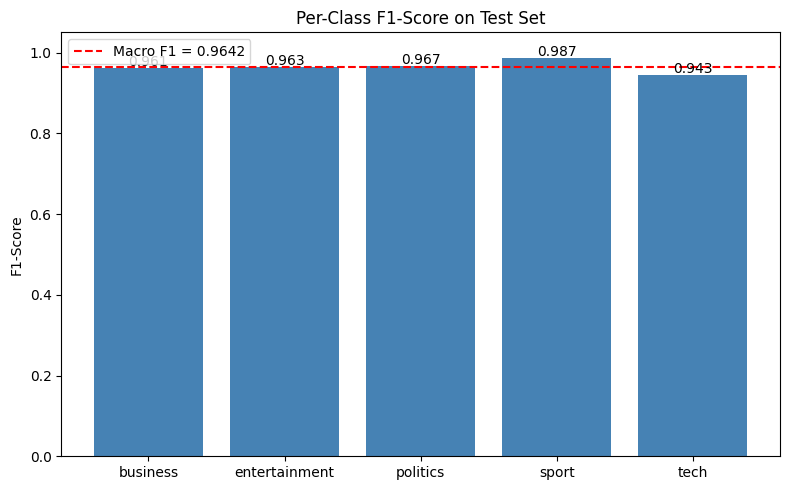


MODEL PERFORMANCE ACROSS PHASES
  Phase 1 — Best feature pipeline Dev F1:  0.9863
  Phase 2 — Best model CV F1 (train):      0.9689 ± 0.0050
  Phase 2.5 — Development set check F1:          0.9771
  Phase 3 — Final Test Macro-F1:            0.9642
  Model:  LinearSVC
  Params: {'C': 5, 'class_weight': 'balanced'}

------------------------------------------------------------
ALL CANDIDATE MODELS (Phase 2 CV Results)
------------------------------------------------------------
  LinearSVC                  CV F1: 0.9689 ± 0.0050
  RandomForest               CV F1: 0.9583 ± 0.0070
  SGDClassifier              CV F1: 0.9398 ± 0.0188
  LogisticRegression         CV F1: 0.9315 ± 0.0140


In [39]:
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)
print(f"Accuracy:        {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Macro Recall:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=le.transform(CATEGORIES))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES,
            yticklabels=CATEGORIES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# true label
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CATEGORIES,
            yticklabels=CATEGORIES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized by True Label)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

#per-Class F1 Bar Chart
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
per_class_f1 = {cat: report_dict[cat]['f1-score'] for cat in CATEGORIES}

plt.figure(figsize=(8, 5))
bars = plt.bar(per_class_f1.keys(), per_class_f1.values(), color='steelblue')
plt.axhline(y=f1_score(y_test, y_pred, average='macro'), color='red',
            linestyle='--', label=f'Macro F1 = {f1_score(y_test, y_pred, average="macro"):.4f}')
for bar, val in zip(bars, per_class_f1.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.3f}',
             ha='center', fontsize=10)
plt.ylim(0, 1.05)
plt.ylabel('F1-Score')
plt.title('Per-Class F1-Score on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

#phases summary
print("\n" + "=" * 60)
print("MODEL PERFORMANCE ACROSS PHASES")
print("=" * 60)
print(f"  Phase 1 — Best feature pipeline Dev F1:  {best_feat['dev_f1']:.4f}")
print(f"  Phase 2 — Best model CV F1 (train):      {best_result['cv_f1']:.4f} ± {best_result['cv_std']:.4f}")
print(f"  Phase 2.5 — Development set check F1:          {phase25_dev_f1:.4f}")
print(f"  Phase 3 — Final Test Macro-F1:            {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Model:  {best_result['name']}")
print(f"  Params: {best_result['params']}")

# ── All Model Comparison on CV ──
print("\n" + "-" * 60)
print("ALL CANDIDATE MODELS (Phase 2 CV Results)")
print("-" * 60)
for r in sorted(phase2_results, key=lambda x: x['cv_f1'], reverse=True):
    print(f"  {r['name']:25s}  CV F1: {r['cv_f1']:.4f} ± {r['cv_std']:.4f}")

## 5.1 Error Analysis

Inspecting misclassified examples reveals common confusion patterns and provides insight into model limitations. This analysis can inform future model refinement.

In [40]:
mask = y_pred != y_test #boolean mask for misclassified samples
errors = pd.DataFrame({
    'true': le.inverse_transform(y_test[mask]), #convert integer labels back to original category names for readability
    'predicted': le.inverse_transform(y_pred[mask]),
    'text': X_test.values[mask]
})

print(f"Total misclassified: {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)\n")

# Most common confusion pairs
print("Most common confusion pairs:")
confusion_pairs = errors.groupby(['true', 'predicted']).size().sort_values(ascending=False) #group by true and predicted labels, count occurrences, sort by count
print(confusion_pairs.head(10).to_string()) #

# Show example misclassifications
print("\n" + "=" * 60)
print("EXAMPLE MISCLASSIFICATIONS")
print("=" * 60)
for i, (_, row) in enumerate(errors.head(5).iterrows()):
    print(f"\n[{i+1}] True: {row['true']} -> Predicted: {row['predicted']}")
    print(f"    Text (first 200 chars): {row['text'][:200]}...")

Total misclassified: 11 / 320 (3.4%)

Most common confusion pairs:
true           predicted    
entertainment  tech             2
tech           business         2
business       entertainment    1
               tech             1
entertainment  politics         1
politics       business         1
               sport            1
               tech             1
sport          business         1

EXAMPLE MISCLASSIFICATIONS

[1] True: politics -> Predicted: tech
    Text (first 200 chars): Parliament's record of scandal. In a locked room at the heart of Parliament there is a hive of scandal.  Sex, betrayal and custody of children are all there in this affair but this time it has nothing...

[2] True: politics -> Predicted: business
    Text (first 200 chars): Hunt ban support is 'in decline'. Support for a ban on hunting has fallen in the past six years, a poll suggests.  Less than half the UK wants a ban compared to almost two-thirds in 1999, the Mori sur...

[3] True: tech -> Predi